# Inverted Double Pendulum — Gymnasium / MuJoCo

The `InvertedDoublePendulum-v5` task is a MuJoCo continuous-control benchmark.  
A cart moves along a frictionless track; two rigid links are stacked above it.  
The goal is to apply horizontal force to the cart so both links stay upright.

**Observation space** (9-dim, Box(-∞, ∞)):

| Index | Symbol | Meaning |
|-------|--------|---------|
| 0 | $x$ | Cart position (m) |
| 1 | $\sin{\theta_1}$ | Sine of hinge-1 angle |
| 2 | $\sin{\theta_2}$ | Sine of hinge-2 angle |
| 3 | $\cos{\theta_1}$ | Cosine of hinge-1 angle |
| 4 | $\sin{\theta_2}$ | Cosine of hinge-2 angle |
| 5 | $\dot{x}$ | Cart velocity (clipped ±10) |
| 6 | $\dot{\theta}_1$ | Hinge-1 angular velocity (clipped ±10) |
| 7 | $\dot{\theta}_2$ | Hinge-2 angular velocity (clipped ±10) |
| 8 | $f_c$ | Constraint force on cart (clipped ±10) |

**Action space** (1-dim, continuous): force on the cart in [−1, 1] N  
**Reward**: `alive_bonus − dist_penalty − vel_penalty`  
**Episode termination**: tip height < 1 m  or  |cart x| > 0.2 m

**State space** (6-dim, angles are periodic):

The actual system state is 6-dimensional — 3 generalized coordinates and their 3 derivatives:

| Variable | Symbol | Description |
|-------|--------|---------|
|qpos[0] | $x$ | Cart position along the track (m) |
|qpos[1] | $\theta_1$ | Angle of the first (lower) link from vertical (rad) |
|qpos[2] | $\theta_2$ | Angle of the second (upper) link relative to the first (rad) |
|qvel[0] | $\dot{x}$ | Cart velocity (m/s) |
|qvel[1] | $\dot{\theta}_1$ | Angular velocity of link 1 (rad/s) |
|qvel[2] | $\dot{\theta}_2$ | Angular velocity of link 2 relative to link 1 (rad/s) |

The observation vector is a transformed encoding of this state — $\theta_1$ and $\theta_2$ are replaced with ($\sin{\theta}$, $\cos{\theta}$) pairs to avoid angle-wrapping discontinuities. In addition, there is a force constraint imposed to prevent the cart from exceeding position limits. The full state can be directly recovered from `env.unwrapped.data.qpos` and `env.unwrapped.data.qvel`.

**TODO** Understand why winding/wrapping matters for RL

## 1. Verify the environment loads

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

print(f"Gymnasium version: {gym.__version__}")

# rgb_array mode lets us capture frames for the animation below
env = gym.make("InvertedDoublePendulum-v5", render_mode="rgb_array")

print(f"Observation space : {env.observation_space}")
print(f"Action space      : {env.action_space}")

Gymnasium version: 1.2.3
Observation space : Box(-inf, inf, (9,), float64)
Action space      : Box(-1.0, 1.0, (1,), float32)


## 2. Inspect a single reset + step

In [2]:
obs, info = env.reset(seed=42)

labels = [
    "cart_x", "sin_θ1", "sin_θ2", "cos_θ1", "cos_θ2",
    "cart_xdot", "θ1dot", "θ2dot", "constraint_force",
]
print("Initial observation (9 values):")
for label, val in zip(labels, obs):
    print(f"  {label:18s}: {val:+.4f}")

action = env.action_space.sample()
next_obs, reward, terminated, truncated, step_info = env.step(action)

print(f"\nAction taken : {action}")
print(f"Reward       : {reward:.4f}")
print(f"Terminated   : {terminated}  |  Truncated: {truncated}")

Initial observation (9 values):
  cart_x            : +0.0548
  sin_θ1            : -0.0122
  sin_θ2            : +0.0717
  cos_θ1            : +0.9999
  cos_θ2            : +0.9974
  cart_xdot         : +0.0941
  θ1dot             : -0.1951
  θ2dot             : -0.1302
  constraint_force  : +0.0000

Action taken : [0.12451503]
Reward       : 9.3538
Terminated   : False  |  Truncated: False


## 3. Run a random-policy episode and collect data

In [3]:
def run_episode(env, policy=None, seed=0, max_steps=1000, capture_frames=False):
    obs, _ = env.reset(seed=seed)
    observations, actions, rewards = [obs], [], []
    frames = [env.render()] if capture_frames else []

    for _ in range(max_steps):
        action = policy(obs) if policy else env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        observations.append(obs)
        actions.append(action)
        rewards.append(reward)
        if capture_frames:
            frames.append(env.render())
        if terminated or truncated:
            break

    return (
        np.array(observations[:-1]),
        np.array(actions),
        np.array(rewards),
        frames,
    )

obs_arr, act_arr, rew_arr, frames = run_episode(env, seed=42, capture_frames=True)

print(f"Episode length    : {len(rew_arr)} steps")
print(f"Total reward      : {rew_arr.sum():.2f}")
print(f"Mean step reward  : {rew_arr.mean():.4f}")
print(f"Observations shape: {obs_arr.shape}")

Episode length    : 5 steps
Total reward      : 35.07
Mean step reward  : 7.0140
Observations shape: (5, 9)


## 4. Visualise the episode as an animation

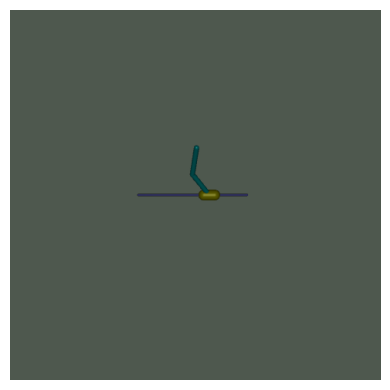

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
im = ax.imshow(np.asarray(frames[0]))

def update(i):
    im.set_data(frames[i])
    return [im]

ani = animation.FuncAnimation(
    fig, update,
    frames=range(0, len(frames), 3),  # every 3rd frame keeps the animation small
    interval=50, blit=True,
)
plt.tight_layout()
HTML(ani.to_jshtml())

## 5. Plot state trajectories

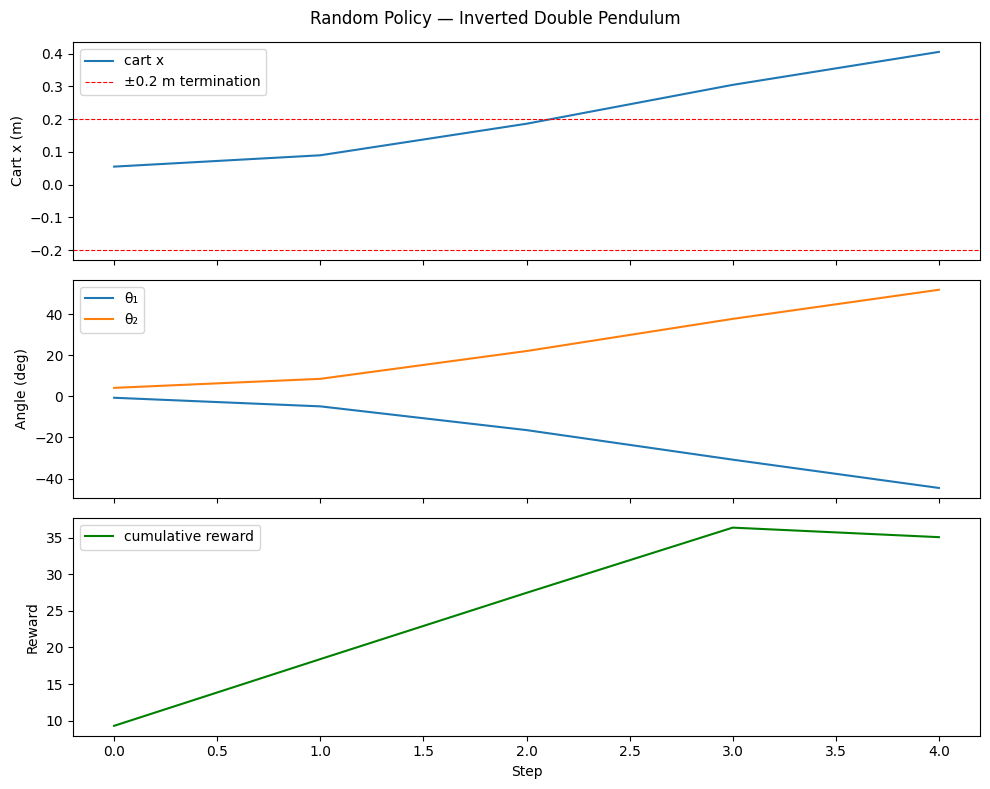

In [5]:
t = np.arange(len(rew_arr))

# Recover angles from sin/cos pairs
theta1 = np.arctan2(obs_arr[:, 1], obs_arr[:, 3])  # atan2(sin θ1, cos θ1)
theta2 = np.arctan2(obs_arr[:, 2], obs_arr[:, 4])

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, obs_arr[:, 0], label="cart x")
axes[0].axhline( 0.2, color="r", ls="--", lw=0.8, label="±0.2 m termination")
axes[0].axhline(-0.2, color="r", ls="--", lw=0.8)
axes[0].set_ylabel("Cart x (m)")
axes[0].legend()

axes[1].plot(t, np.degrees(theta1), label="θ₁")
axes[1].plot(t, np.degrees(theta2), label="θ₂")
axes[1].set_ylabel("Angle (deg)")
axes[1].legend()

axes[2].plot(t, np.cumsum(rew_arr), color="green", label="cumulative reward")
axes[2].set_ylabel("Reward")
axes[2].set_xlabel("Step")
axes[2].legend()

fig.suptitle("Random Policy — Inverted Double Pendulum")
plt.tight_layout()
plt.show()

## 6. Sanity-check: episode-length distribution over many random episodes

Over 50 random-policy episodes:
  Median episode length : 6 steps
  Mean total reward     : 48.4


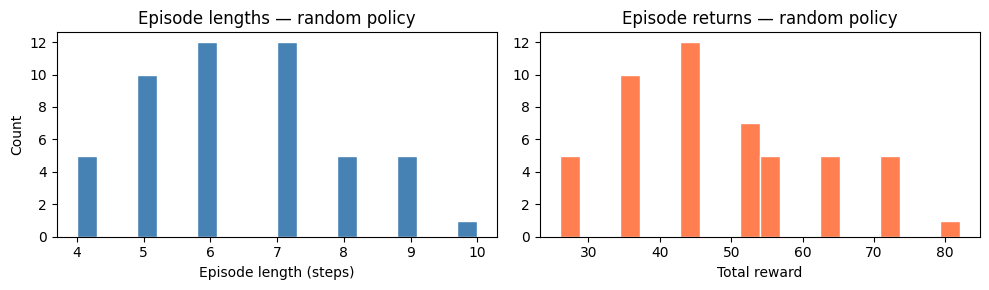

In [6]:
n_episodes = 50
lengths, totals = [], []

# Use a headless env (no rendering) for speed
fast_env = gym.make("InvertedDoublePendulum-v5")
for seed in range(n_episodes):
    _, _, rews, _ = run_episode(fast_env, seed=seed)
    lengths.append(len(rews))
    totals.append(rews.sum())
fast_env.close()

print(f"Over {n_episodes} random-policy episodes:")
print(f"  Median episode length : {np.median(lengths):.0f} steps")
print(f"  Mean total reward     : {np.mean(totals):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(lengths, bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Episode length (steps)")
axes[0].set_ylabel("Count")
axes[0].set_title("Episode lengths — random policy")

axes[1].hist(totals, bins=20, color="coral", edgecolor="white")
axes[1].set_xlabel("Total reward")
axes[1].set_title("Episode returns — random policy")

plt.tight_layout()
plt.show()

## 7. Clean up

In [7]:
env.close()
print("Environment closed. Ready to start training!")

Environment closed. Ready to start training!
